In [15]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
train_dir = "./Epic and CSCR hospital Dataset/Train/"
test_dir  = "./Epic and CSCR hospital Dataset/Test/"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2            
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1/255)

test_data =  test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 7722 images belonging to 4 classes.
Found 1928 images belonging to 4 classes.
Found 2414 images belonging to 4 classes.


In [3]:
from tensorflow.keras import layers, models, regularizers

def build_cnn():
    model = models.Sequential([
        
        # Bloque 1
        layers.Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Bloque 2
        layers.Conv2D(64, (3,3), padding="same"),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.30),

        # Bloque 3
        layers.Conv2D(128, (3,3), padding="same"),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.35),

        # Bloque 4
        layers.Conv2D(256, (3,3), padding="same"),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.40),

        layers.Flatten(),

        # Fully Connected
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.1),
        layers.Dropout(0.5),

        layers.Dense(train_data.num_classes, activation='softmax')
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn = build_cnn()
cnn.summary()


c:\Users\perez\OneDrive\Escritorio\Codigos\diplo_entv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\perez\OneDrive\Escritorio\Codigos\diplo_entv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 13,237,700 (50.50 MB)

 Trainable params: 13,236,228 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [4]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='accuracy', patience=12)

In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint(
    filepath='models_base/model_{val_accuracy:.3f}.keras',  
    monitor='val_accuracy',            
    mode='max',                   
    save_best_only=True,         
    save_weights_only=False,      
    verbose=1
)

In [6]:
history_cnn = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=100,             # aumenta épocas para aprovechar regularización
    verbose=1,
    batch_size=16,
    callbacks=[checkpoint, early_stopping]
)


Epoch 1/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4799 - loss: 1.4457
Epoch 1: val_accuracy improved from None to 0.31380, saving model to models_base/model_0.314.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.5164 - loss: 1.2459 - val_accuracy: 0.3138 - val_loss: 3.0575
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6129 - loss: 0.9926
Epoch 2: val_accuracy improved from 0.31380 to 0.46525, saving model to models_base/model_0.465.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.6248 - loss: 0.9680 - val_accuracy: 0.4652 - val_loss: 1.3327
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6528 - loss: 0.8707
Epoch 3: val_accuracy did not improve from 0.46525
242/242 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.6709 - loss: 0.8390 - val_accuracy: 0.2910 - val_loss: 2.9370
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7140 - loss: 0.7714
Epoch 4: val_accuracy did not improve from 0.46525

In [16]:
results = pd.DataFrame(history_cnn.history)

In [17]:
import plotly.express as px
fig = px.line(results, y=['accuracy', 'val_accuracy'], title='Model Accuracy')
fig.show()

In [19]:
import re
folder = "models_base"
pattern = re.compile(r"model_([0-9]+\.[0-9]+)\.keras")  # captura el 0.323

best_file = None
best_acc = -1.0

for fname in os.listdir(folder):
    m = pattern.search(fname)
    if m:
        acc = float(m.group(1))
        if acc > best_acc:
            best_acc = acc
            best_file = os.path.join(folder, fname)

if best_file is None:
    raise FileNotFoundError(f"No se encontraron archivos con el patrón en {folder}")

print(f"Cargando mejor modelo: {best_file}  (val_accuracy = {best_acc:.3f})")
model = tf.keras.models.load_model(best_file)
model.summary()

Cargando mejor modelo: models_base\model_0.904.keras  (val_accuracy = 0.904)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 39,710,158 (151.48 MB)

 Trainable params: 13,236,228 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 26,472,458 (100.98 MB)

In [20]:
loss, acc = model.evaluate(test_data)
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")


76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 199ms/step - accuracy: 0.9027 - loss: 0.2969
Test loss: 0.2969, Test accuracy: 0.9027


In [50]:
import random
import numpy as np

# Número de batches disponibles
num_batches = len(val_data)

# Elegimos un batch aleatorio
batch_index = random.randint(0, num_batches-1)

images, labels = val_data[batch_index]  

# Seleccionar 5 índices del batch
idxs = random.sample(range(len(images)), 10)

selected_images = [images[i] for i in idxs]
selected_labels = [labels[i] for i in idxs]

print("🚀 10 imágenes seleccionadas correctamente desde DirectoryIterator")


🚀 10 imágenes seleccionadas correctamente desde DirectoryIterator


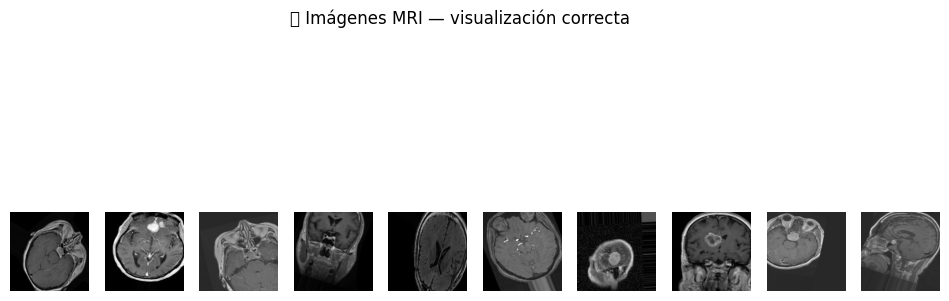

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
for i, img in enumerate(selected_images):
    plt.subplot(1,10,i+1)

   
    if img.shape[-1] == 1:  
        plt.imshow(img[:,:,0], cmap='gray')
    else:
        plt.imshow(img)    

    plt.axis("off")

plt.suptitle("🧠 Imágenes MRI — visualización correcta")
plt.show()



In [ ]:
import numpy as np


images_array = np.array(selected_images)


preds = model.predict(images_array)


pred_labels = np.argmax(preds, axis=1)
confidences = np.max(preds, axis=1)


class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]  

print("\n🔍 Resultados del modelo:\n")
for i in range(10):
    real_index = int(np.argmax(selected_labels[i]))  
    pred_index = int(pred_labels[i])

    real = class_names[real_index]
    pred = class_names[pred_index]
    conf = confidences[i] * 100

    print(f"🧠 Imagen {i+1}")
    print(f"   ✔ Real       → {real}")
    print(f"   🔮 Predicción → {pred}  ({conf:.2f}% de confianza)")
    print("-" * 45)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

🔍 Resultados del modelo:

🧠 Imagen 1
   ✔ Real       → pituitary
   🔮 Predicción → pituitary  (99.24% de confianza)
---------------------------------------------
🧠 Imagen 2
   ✔ Real       → meningioma
   🔮 Predicción → meningioma  (81.23% de confianza)
---------------------------------------------
🧠 Imagen 3
   ✔ Real       → pituitary
   🔮 Predicción → pituitary  (84.69% de confianza)
---------------------------------------------
🧠 Imagen 4
   ✔ Real       → glioma
   🔮 Predicción → glioma  (35.30% de confianza)
---------------------------------------------
🧠 Imagen 5
   ✔ Real       → no_tumor
   🔮 Predicción → no_tumor  (99.63% de confianza)
---------------------------------------------
🧠 Imagen 6
   ✔ Real       → no_tumor
   🔮 Predicción → no_tumor  (99.96% de confianza)
---------------------------------------------
🧠 Imagen 7
   ✔ Real       → meningioma
   🔮 Predicción → meningioma  (90.75% de confianza)
-----------------------------------